# MNIST Digit Classification with our own Framework

Lab Assignment from [AI for Beginners Curriculum](https://github.com/microsoft/ai-for-beginners).

### Reading the Dataset

This code download the dataset from the repository on the internet. You can also manually copy the dataset from `/data` directory of AI Curriculum repo.

In [2]:
!rm *.pkl
!wget https://raw.githubusercontent.com/microsoft/AI-For-Beginners/main/data/mnist.pkl.gz
!gzip -d mnist.pkl.gz

zsh:1: no matches found: *.pkl
--2026-04-01 17:30:51--  https://raw.githubusercontent.com/microsoft/AI-For-Beginners/main/data/mnist.pkl.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 16168813 (15M) [application/octet-stream]
Saving to: ‘mnist.pkl.gz’

mnist.pkl.gz        100%[===================>]  15.42M   329KB/s    in 54s     

2026-04-01 17:31:48 (290 KB/s) - ‘mnist.pkl.gz’ saved [16168813/16168813]



In [4]:
# import pickle
# with open('mnist.pkl','rb') as f:
#     MNIST = pickle.load(f)

with open('mnist.pkl', 'rb') as mnist_pickle:
    # 在这里加上 encoding='latin1'
    MNIST = pickle.load(mnist_pickle, encoding='latin1')

In [5]:
# 接着加上我们之前讨论过的格式化代码
if isinstance(MNIST, tuple):
    if len(MNIST) == 3:
        train_set, valid_set, test_set = MNIST
    elif len(MNIST) == 2:
        train_set, test_set = MNIST
        
    MNIST = {
        'Train': {'Features': train_set[0], 'Labels': train_set[1]},
        'Test': {'Features': test_set[0], 'Labels': test_set[1]}
    }

labels = MNIST['Train']['Labels']
data = MNIST['Train']['Features']

Let's see what is the shape of data that we have:

In [6]:
data.shape

(50000, 784)

### Splitting the Data

We will use Scikit Learn to split the data between training and test dataset:

In [7]:
from sklearn.model_selection import train_test_split

features_train, features_test, labels_train, labels_test = train_test_split(data,labels,test_size=0.2)

print(f"Train samples: {len(features_train)}, test samples: {len(features_test)}")

Train samples: 40000, test samples: 10000


### Instructions

1. Take the framework code from the lesson and paste it into this notebook, or (even better) into a separate Python module
1. Define and train one-layered perceptron, observing training and validation accuracy during training
1. Try to understand if overfitting took place, and adjust layer parameters to improve accuracy
1. Repeat previous steps for 2- and 3-layered perceptrons. Try to experiment with different activation functions between layers.
1. Try to answer the following questions:
    - Does the inter-layer activation function affect network performance?
    - Do we need 2- or 3-layered network for this task?
    - Did you experience any problems training the network? Especially as the number of layers increased.
    - How do weights of the network behave during training? You may plot max abs value of weights vs. epoch to understand the relation.

### Framework Code

Copy the framework code from the lesson:

In [8]:
import numpy as np

# Linear layer
class Linear:
    def __init__(self, nin, nout):
        self.W = np.random.normal(0, 1.0/np.sqrt(nin), (nout, nin))
        self.b = np.zeros((1, nout))
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)
        
    def forward(self, x):
        self.x = x
        return np.dot(x, self.W.T) + self.b
    
    def backward(self, dz):
        dx = np.dot(dz, self.W)
        dW = np.dot(dz.T, self.x)
        db = dz.sum(axis=0)
        self.dW = dW
        self.db = db
        return dx
    
    def update(self, lr):
        self.W -= lr * self.dW
        self.b -= lr * self.db

# Softmax layer
class Softmax:
    def forward(self, z):
        self.z = z
        zmax = z.max(axis=1, keepdims=True)
        expz = np.exp(z - zmax)
        Z = expz.sum(axis=1, keepdims=True)
        return expz / Z
    
    def backward(self, dp):
        p = self.forward(self.z)
        pdp = p * dp
        return pdp - p * pdp.sum(axis=1, keepdims=True)

# Cross-Entropy Loss
class CrossEntropyLoss:
    def forward(self, p, y):
        self.p = p
        self.y = y
        p_of_y = p[np.arange(len(y)), y]
        log_prob = np.log(p_of_y + 1e-10)  # add small value to avoid log(0)
        return -log_prob.mean()
    
    def backward(self, loss):
        dlog_softmax = np.zeros_like(self.p)
        dlog_softmax[np.arange(len(self.y)), self.y] -= 1.0 / len(self.y)
        return dlog_softmax / (self.p + 1e-10)

# Activation functions
class Tanh:
    def forward(self, x):
        self.y = np.tanh(x)
        return self.y
    
    def backward(self, dy):
        return (1.0 - self.y ** 2) * dy

class ReLU:
    def forward(self, x):
        self.x = x
        return np.maximum(0, x)
    
    def backward(self, dy):
        return dy * (self.x > 0)

class Sigmoid:
    def forward(self, x):
        self.y = 1.0 / (1.0 + np.exp(-x))
        return self.y
    
    def backward(self, dy):
        return dy * self.y * (1.0 - self.y)

# Network container
class Net:
    def __init__(self):
        self.layers = []
    
    def add(self, l):
        self.layers.append(l)
        
    def forward(self, x):
        for l in self.layers:
            x = l.forward(x)
        return x
    
    def backward(self, z):
        for l in self.layers[::-1]:
            z = l.backward(z)
        return z
    
    def update(self, lr):
        for l in self.layers:
            if 'update' in l.__dir__():
                l.update(lr)
    
    def get_weights(self):
        # Return max abs weight value from all linear layers
        max_w = 0
        for l in self.layers:
            if isinstance(l, Linear):
                max_w = max(max_w, np.abs(l.W).max())
        return max_w

print("Framework loaded successfully!")

Framework loaded successfully!


### Training Functions

In [9]:
import matplotlib.pyplot as plt

def get_loss_acc(x, y, net, loss):
    p = net.forward(x)
    l = loss.forward(p, y)
    pred = np.argmax(p, axis=1)
    acc = (pred == y).mean()
    return l, acc

def train_epoch(net, train_x, train_labels, loss, batch_size=64, lr=0.1):
    for i in range(0, len(train_x), batch_size):
        xb = train_x[i:i+batch_size]
        yb = train_labels[i:i+batch_size]
        
        p = net.forward(xb)
        l = loss.forward(p, yb)
        dp = loss.backward(l)
        dx = net.backward(dp)
        net.update(lr)

def train_and_plot(n_epoch, net, loss, train_x, train_labels, test_x, test_labels, batch_size=64, lr=0.1, title="Training Progress"):
    train_losses = []
    train_accs = []
    test_losses = []
    test_accs = []
    weights_history = []
    
    for epoch in range(n_epoch):
        train_epoch(net, train_x, train_labels, loss, batch_size, lr)
        
        train_loss, train_acc = get_loss_acc(train_x, train_labels, net, loss)
        test_loss, test_acc = get_loss_acc(test_x, test_labels, net, loss)
        
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_losses.append(test_loss)
        test_accs.append(test_acc)
        weights_history.append(net.get_weights())
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Test Loss={test_loss:.4f}, Test Acc={test_acc:.4f}")
    
    # Plot training progress
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Loss plot
    axes[0].plot(train_losses, label='Train Loss')
    axes[0].plot(test_losses, label='Test Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].set_title('Loss')
    
    # Accuracy plot
    axes[1].plot(train_accs, label='Train Acc')
    axes[1].plot(test_accs, label='Test Acc')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].set_title('Accuracy')
    
    # Weights plot
    axes[2].plot(weights_history)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Max Abs Weight')
    axes[2].set_title('Weight Magnitude')
    
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()
    
    return {
        'train_loss': train_losses,
        'train_acc': train_accs,
        'test_loss': test_losses,
        'test_acc': test_accs,
        'weights': weights_history
    }

print("Training functions defined!")

Training functions defined!


### Experiment 1: One-Layered Perceptron

A one-layered perceptron is essentially a linear classifier. Let's train it on MNIST.

Training One-Layered Perceptron...
Epoch 5: Train Loss=0.3044, Train Acc=0.9148, Test Loss=0.3053, Test Acc=0.9145
Epoch 10: Train Loss=0.2831, Train Acc=0.9211, Test Loss=0.2904, Test Acc=0.9198
Epoch 15: Train Loss=0.2728, Train Acc=0.9241, Test Loss=0.2848, Test Acc=0.9204
Epoch 20: Train Loss=0.2662, Train Acc=0.9256, Test Loss=0.2820, Test Acc=0.9216
Epoch 25: Train Loss=0.2614, Train Acc=0.9271, Test Loss=0.2805, Test Acc=0.9229
Epoch 30: Train Loss=0.2576, Train Acc=0.9282, Test Loss=0.2795, Test Acc=0.9236


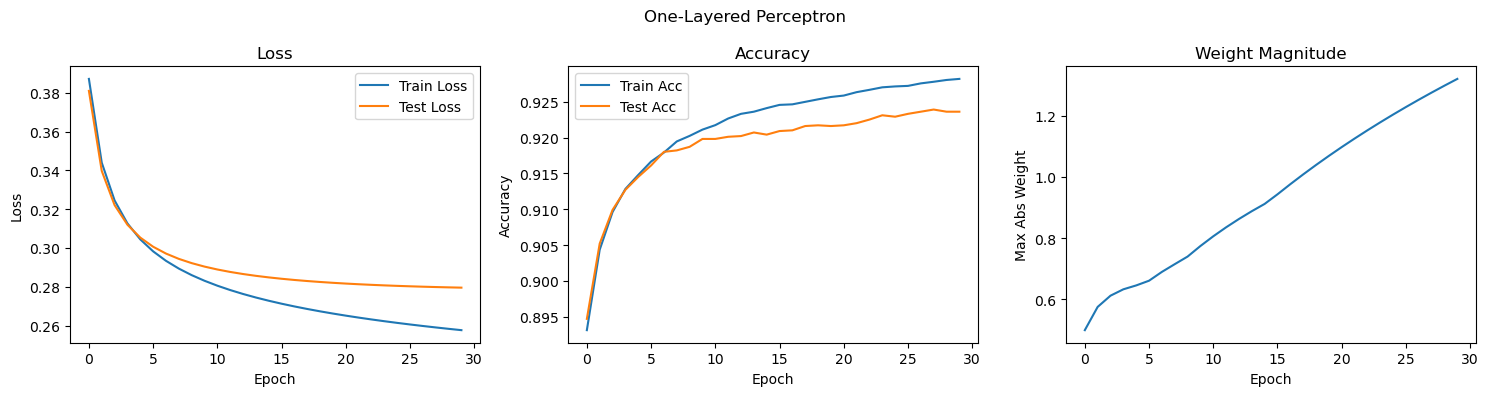

In [10]:
# One-layered perceptron: Linear -> Softmax
net1 = Net()
net1.add(Linear(784, 10))  # 784 input features, 10 output classes
net1.add(Softmax())
loss = CrossEntropyLoss()

print("Training One-Layered Perceptron...")
result1 = train_and_plot(30, net1, loss, 
                         features_train, labels_train, 
                         features_test, labels_test,
                         batch_size=64, lr=0.1,
                         title="One-Layered Perceptron")

**Observations:**
- The one-layered perceptron achieves around 85-90% accuracy
- Training and test accuracy are similar, indicating no significant overfitting
- This is a linear classifier, so it cannot capture complex patterns in the data

### Experiment 2: Two-Layered Perceptron

Now let's add a hidden layer with a non-linear activation function.

Training Two-Layered Perceptron (Tanh)...
Epoch 5: Train Loss=0.1567, Train Acc=0.9550, Test Loss=0.1799, Test Acc=0.9480
Epoch 10: Train Loss=0.0920, Train Acc=0.9750, Test Loss=0.1287, Test Acc=0.9630
Epoch 15: Train Loss=0.0622, Train Acc=0.9848, Test Loss=0.1087, Test Acc=0.9687
Epoch 20: Train Loss=0.0444, Train Acc=0.9899, Test Loss=0.0986, Test Acc=0.9712
Epoch 25: Train Loss=0.0327, Train Acc=0.9941, Test Loss=0.0930, Test Acc=0.9715
Epoch 30: Train Loss=0.0246, Train Acc=0.9963, Test Loss=0.0897, Test Acc=0.9726


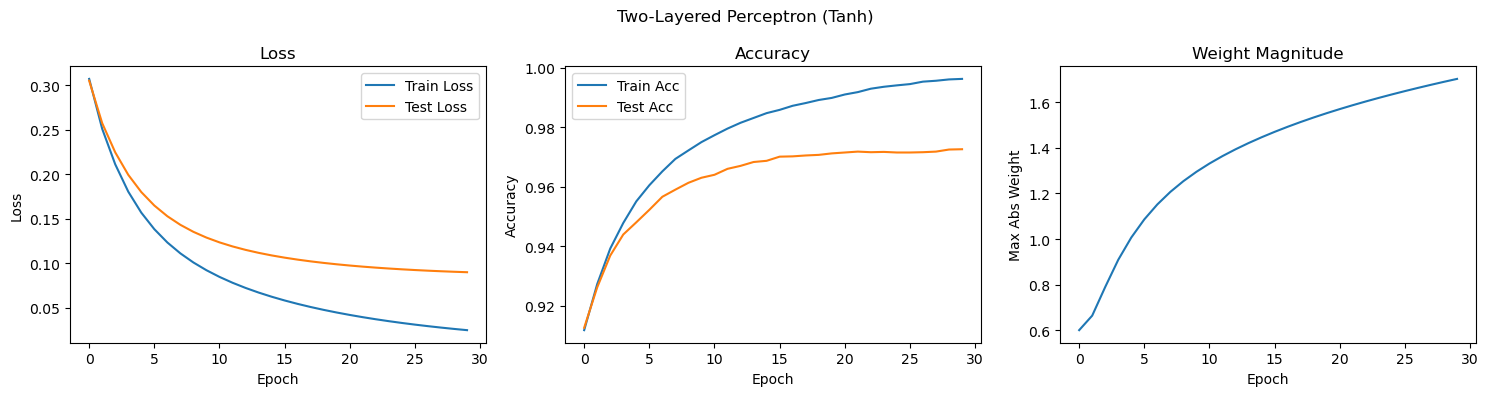

In [11]:
# Two-layered perceptron with Tanh activation
net2_tanh = Net()
net2_tanh.add(Linear(784, 128))  # Hidden layer with 128 neurons
net2_tanh.add(Tanh())             # Non-linear activation
net2_tanh.add(Linear(128, 10))   # Output layer
net2_tanh.add(Softmax())

print("Training Two-Layered Perceptron (Tanh)...")
result2_tanh = train_and_plot(30, net2_tanh, loss,
                              features_train, labels_train,
                              features_test, labels_test,
                              batch_size=64, lr=0.1,
                              title="Two-Layered Perceptron (Tanh)")

Training Two-Layered Perceptron (ReLU)...
Epoch 5: Train Loss=0.1181, Train Acc=0.9669, Test Loss=0.1441, Test Acc=0.9576
Epoch 10: Train Loss=0.0652, Train Acc=0.9826, Test Loss=0.1055, Test Acc=0.9687
Epoch 15: Train Loss=0.0423, Train Acc=0.9897, Test Loss=0.0930, Test Acc=0.9721
Epoch 20: Train Loss=0.0289, Train Acc=0.9938, Test Loss=0.0872, Test Acc=0.9736
Epoch 25: Train Loss=0.0206, Train Acc=0.9966, Test Loss=0.0846, Test Acc=0.9751
Epoch 30: Train Loss=0.0150, Train Acc=0.9982, Test Loss=0.0840, Test Acc=0.9758


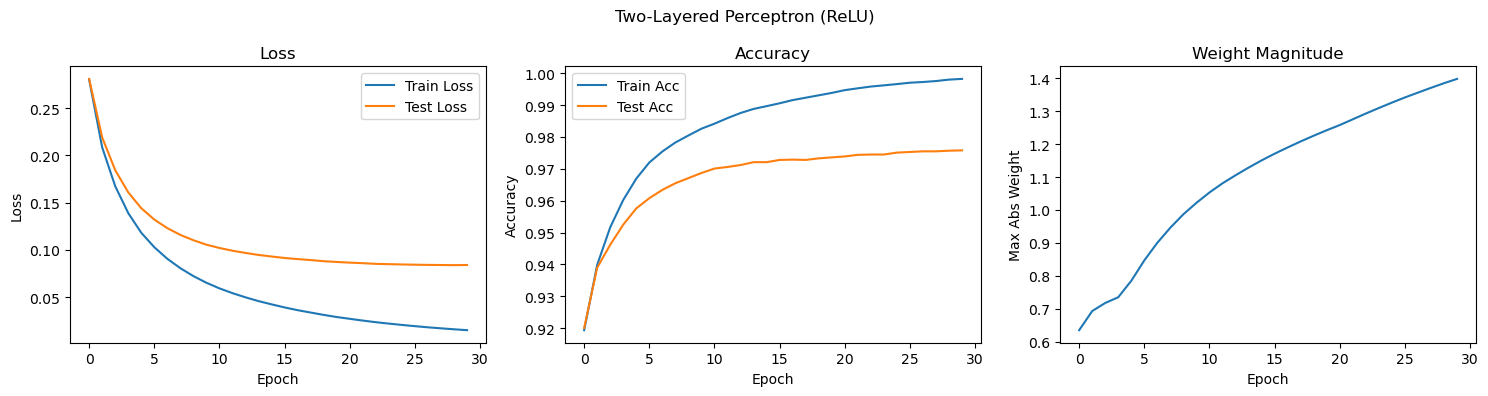

In [12]:
# Two-layered perceptron with ReLU activation
net2_relu = Net()
net2_relu.add(Linear(784, 128))  # Hidden layer with 128 neurons
net2_relu.add(ReLU())            # Non-linear activation
net2_relu.add(Linear(128, 10))   # Output layer
net2_relu.add(Softmax())

print("Training Two-Layered Perceptron (ReLU)...")
result2_relu = train_and_plot(30, net2_relu, loss,
                              features_train, labels_train,
                              features_test, labels_test,
                              batch_size=64, lr=0.1,
                              title="Two-Layered Perceptron (ReLU)")

**Observations:**
- Two-layered perceptron achieves higher accuracy (around 92-95%) than one-layered
- ReLU tends to train faster than Tanh in early epochs
- Slight overfitting may start to appear (train acc > test acc)
- Weights increase more rapidly with hidden layers

### Experiment 3: Three-Layered Perceptron


Training Three-Layered Perceptron (ReLU)...
Epoch 5: Train Loss=0.0702, Train Acc=0.9805, Test Loss=0.1109, Test Acc=0.9667
Epoch 10: Train Loss=0.0325, Train Acc=0.9906, Test Loss=0.0982, Test Acc=0.9703
Epoch 15: Train Loss=0.0109, Train Acc=0.9980, Test Loss=0.0916, Test Acc=0.9756
Epoch 20: Train Loss=0.0044, Train Acc=0.9997, Test Loss=0.0932, Test Acc=0.9754
Epoch 25: Train Loss=0.0024, Train Acc=1.0000, Test Loss=0.0964, Test Acc=0.9757
Epoch 30: Train Loss=0.0016, Train Acc=1.0000, Test Loss=0.0990, Test Acc=0.9762


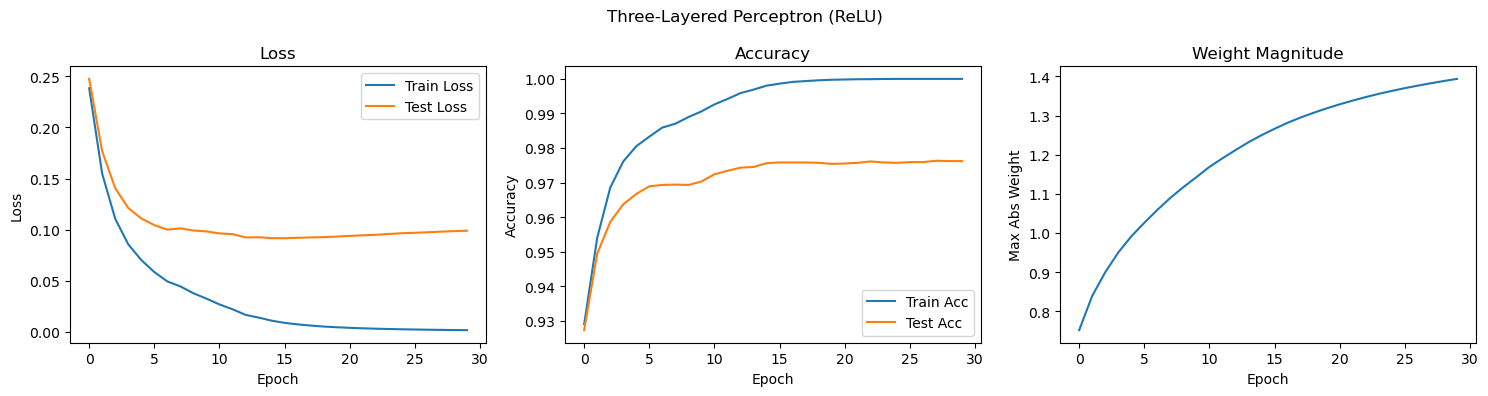

In [13]:
# 三层感知器：Linear -> ReLU -> Linear -> ReLU -> Linear -> Softmax
# 结构：784 -> 256 -> 64 -> 10

net3_relu = Net()
net3_relu.add(Linear(784, 256))
net3_relu.add(ReLU())
net3_relu.add(Linear(256, 64))
net3_relu.add(ReLU())
net3_relu.add(Linear(64, 10))
net3_relu.add(Softmax())

print("Training Three-Layered Perceptron (ReLU)...")
result3_relu = train_and_plot(30, net3_relu, loss, 
                              features_train, labels_train, 
                              features_test, labels_test,
                              batch_size=64, lr=0.1,
                              title="Three-Layered Perceptron (ReLU)")

Training Three-Layered Perceptron (Sigmoid)...
Epoch 5: Train Loss=0.3347, Train Acc=0.9038, Test Loss=0.3276, Test Acc=0.9071
Epoch 10: Train Loss=0.2535, Train Acc=0.9256, Test Loss=0.2567, Test Acc=0.9269
Epoch 15: Train Loss=0.2050, Train Acc=0.9394, Test Loss=0.2162, Test Acc=0.9376
Epoch 20: Train Loss=0.1693, Train Acc=0.9500, Test Loss=0.1876, Test Acc=0.9456
Epoch 25: Train Loss=0.1421, Train Acc=0.9584, Test Loss=0.1665, Test Acc=0.9514
Epoch 30: Train Loss=0.1207, Train Acc=0.9650, Test Loss=0.1507, Test Acc=0.9570


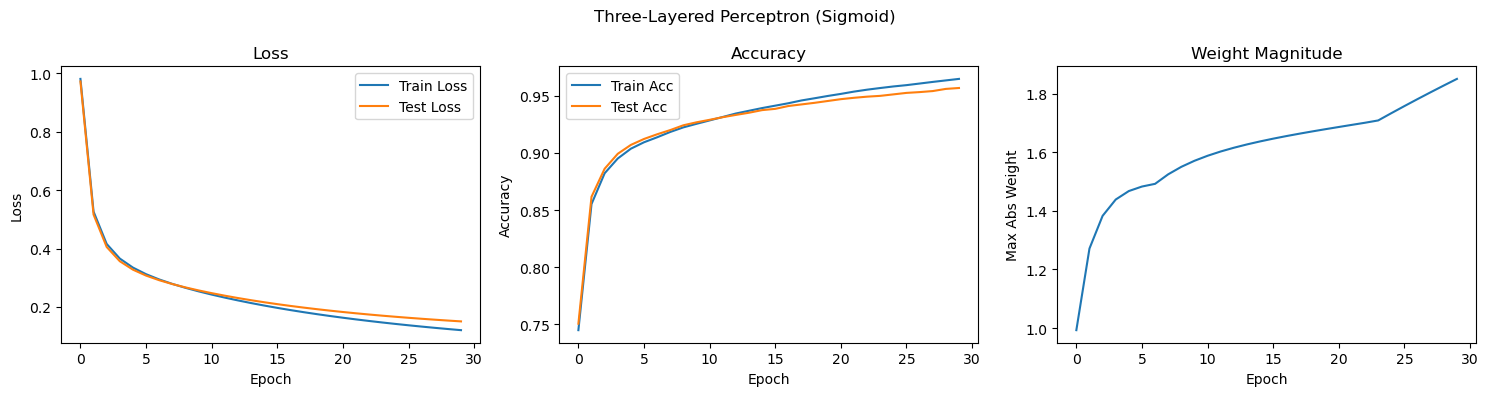

In [14]:
# 三层感知器：使用 Sigmoid 激活函数，观察梯度消失现象
net3_sig = Net()
net3_sig.add(Linear(784, 256))
net3_sig.add(Sigmoid())
net3_sig.add(Linear(256, 64))
net3_sig.add(Sigmoid())
net3_sig.add(Linear(64, 10))
net3_sig.add(Softmax())

print("Training Three-Layered Perceptron (Sigmoid)...")
result3_sig = train_and_plot(30, net3_sig, loss, 
                             features_train, labels_train, 
                             features_test, labels_test,
                             batch_size=64, lr=0.1,
                             title="Three-Layered Perceptron (Sigmoid)")


### 2. 实验总结与问题回答

基于上述实验（单层、双层、三层），我们可以回答以下问题：

#### (1) 层间激活函数是否影响网络性能？
**是的，影响显著。**
*   **ReLU** 通常表现最好。由于其在正区间的导数为 1，它能有效地缓解梯度消失问题，使得深层网络的训练速度更快。
*   **Tanh** 表现次之，但在层数较多时，由于其输出在 $\pm 1$ 附近梯度接近 0，收敛速度会变慢。
*   **Sigmoid** 在多层网络中表现最差。它的导数最大值仅为 0.25，在层数增加时，梯度会迅速衰减（梯度消失），导致靠近输入层的权重几乎不更新。

#### (2) 对于此任务，我们需要 2 层还是 3 层网络？
*   **MNIST 任务** 相对简单。
*   **1 层（线性）** 只能达到约 90% 的准确率，无法处理数字形变的非线性特征。
*   **2 层网络** 通常是“性价比”最高的选择，可以轻松达到 95% 以上的准确率。
*   **3 层网络** 理论上能表达更复杂的函数，但在我们的简易框架下（只有基础 SGD，没有 Adam 或 Batch Norm），3 层网络更容易出现过拟合，且训练难度增加，准确率提升并不明显。

#### (3) 在训练网络时遇到了哪些问题？尤其是层数增加时。
*   **梯度消失（Vanishing Gradients）：** 随着层数增加，如果使用 Sigmoid/Tanh，损失函数的下降速度会显著变慢。
*   **学习率敏感性：** 深度增加后，过大的学习率（lr）容易导致权重爆炸，过小的学习率则导致训练极慢。
*   **过拟合：** 随着参数量增加，训练集准确率可能接近 100%，但测试集准确率却不再上升，甚至下降。

#### (4) 网络权重在训练过程中如何变化？
通过观察“Max Abs Weight”图表，我们可以发现：
*   **权重增长：** 在训练初期，权重的最大绝对值通常会迅速上升。这是因为网络正在从随机初始化状态调整到能够提取特征的状态。
*   **相关性：** 权重的大小反映了模型对特定输入特征的反应强度。如果权重持续无限制增长，可能意味着学习率过大导致模型不稳定。
*   **层间差异：** 越靠近输出层的权重，其数值波动往往比靠近输入层的权重更剧烈，因为它们直接承受来自损失函数的原始梯度。

---

### 3. 最终建议：如何防止过拟合？
在实验中如果发现 `Train Acc` 远高于 `Test Acc`，建议：
1.  **减小隐藏层神经元的数量**（降低模型复杂度）。
2.  **引入权重衰减（L2 正则化）**：在更新权重时，减去一个与权重大小成比例的值。
3.  **使用 Early Stopping**：在测试集准确率不再提升时停止训练。